# E-OBS and ECMWF Data Merging with Seasonal Analysis

## Data Sources:
- **E-OBS**: Observational data (pp, rr, tg, wet_day_frequency, spi_1_values) with lagged variables
- **ECMWF**: Seasonal forecast ensemble mean and variance (t2m, tprate, msl)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os

# 1. Load Data


In [33]:
core_folder = "000000 Final Data/eastnor"

In [ ]:
eobs_df = pd.read_csv(f"{core_folder}/2_eobs_pp_tg_rr_spi_wdf_df.csv")

ecmwf_df = pd.read_csv(f"{core_folder}/1_ecmwf_eastnor_df_ensmean_ensvar.csv")
if 'Unnamed: 0' in ecmwf_df.columns:
    ecmwf_df = ecmwf_df.drop(columns=['Unnamed: 0'])

print("✓ Data loaded successfully")
print(f"  E-OBS shape: {eobs_df.shape}")
print(f"  ECMWF shape: {ecmwf_df.shape}")

✓ Data loaded successfully
  E-OBS shape: (378, 12)
  ECMWF shape: (372, 7)


## 1.1 Inspect Loaded Data


In [35]:
print("E-OBS DataFrame (first 3 rows):")
display(eobs_df.head(3))
print("\nE-OBS columns:")
print(eobs_df.columns.tolist())

E-OBS DataFrame (first 3 rows):


,time,eobs_pp,eobs_pp_-1,eobs_pp_-2,eobs_rr,eobs_rr_-1,eobs_rr_-2,eobs_tg,eobs_tg_-1,eobs_tg_-2,eobs_wet_day_frequency,eobs_spi_1_values
0,1993-01-31,998.9473,NaN,NaN,38.970314,NaN,NaN,-5.261134,NaN,NaN,0.391633,0.051676
1,1993-02-28,1018.1386,998.9473,NaN,25.704689,38.970314,NaN,-4.456501,-5.261134,NaN,0.235491,-0.085867
2,1993-03-31,1014.4976,1018.1386,998.9473,6.095313,25.704689,38.970314,-3.907354,-4.456501,-5.261134,0.121976,-1.862051



E-OBS columns:
['time', 'eobs_pp', 'eobs_pp_-1', 'eobs_pp_-2', 'eobs_rr', 'eobs_rr_-1', 'eobs_rr_-2', 'eobs_tg', 'eobs_tg_-1', 'eobs_tg_-2', 'eobs_wet_day_frequency', 'eobs_spi_1_values']


In [36]:
print("ECMWF DataFrame (first 3 rows):")
display(ecmwf_df.head(3))
print("\nECMWF columns:")
print(ecmwf_df.columns.tolist())


ECMWF DataFrame (first 3 rows):


,time,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean,ecmwf_t2m_ensvar,ecmwf_tprate_ensvar,ecmwf_msl_ensvar
0,1993-01-31,-9.995088,56.371018,1016.700414,4.592152,357.833429,100.415007
1,1993-02-28,-7.576119,60.481235,1010.595649,1.361122,187.826222,13.545122
2,1993-03-31,-6.818393,45.683977,1009.978842,1.784359,232.807868,34.732208



ECMWF columns:
['time', 'ecmwf_t2m_ensmean', 'ecmwf_tprate_ensmean', 'ecmwf_msl_ensmean', 'ecmwf_t2m_ensvar', 'ecmwf_tprate_ensvar', 'ecmwf_msl_ensvar']


# 2. Data Consistency Checks


In [ ]:
eobs_df['time'] = pd.to_datetime(eobs_df['time'])
ecmwf_df['time'] = pd.to_datetime(ecmwf_df['time'])

print("="*70)
print("TIME DIMENSION COMPARISON")
print("="*70)

print("E-OBS:")
print(f"  Number of months: {len(eobs_df)}")
print(f"  Date range: {eobs_df['time'].min()} to {eobs_df['time'].max()}")
print(f"  Years covered: {eobs_df['time'].dt.year.min()} - {eobs_df['time'].dt.year.max()}")

print("\nECMWF:")
print(f"  Number of months: {len(ecmwf_df)}")
print(f"  Date range: {ecmwf_df['time'].min()} to {ecmwf_df['time'].max()}")
print(f"  Years covered: {ecmwf_df['time'].dt.year.min()} - {ecmwf_df['time'].dt.year.max()}")

# Find time overlaps
eobs_times = set(eobs_df['time'])
ecmwf_times = set(ecmwf_df['time'])

common_times = eobs_times & ecmwf_times
eobs_only = eobs_times - ecmwf_times
ecmwf_only = ecmwf_times - eobs_times

print("\nTime Overlap Analysis:")
print(f"  Common months: {len(common_times)}")
print(f"  Only in E-OBS: {len(eobs_only)}")
print(f"  Only in ECMWF: {len(ecmwf_only)}")

if eobs_only:
    print(f"\n  Months only in E-OBS:")
    for t in sorted(eobs_only):
        print(f"    - {t.strftime('%Y-%m-%d')}")

if ecmwf_only:
    print(f"\n  Months only in ECMWF:")
    for t in sorted(ecmwf_only):
        print(f"    - {t.strftime('%Y-%m-%d')}")

TIME DIMENSION COMPARISON
E-OBS:
  Number of months: 378
  Date range: 1993-01-31 00:00:00 to 2024-06-30 00:00:00
  Years covered: 1993 - 2024

ECMWF:
  Number of months: 372
  Date range: 1993-01-31 00:00:00 to 2023-12-31 00:00:00
  Years covered: 1993 - 2023

Time Overlap Analysis:
  Common months: 372
  Only in E-OBS: 6
  Only in ECMWF: 0

  Months only in E-OBS:
    - 2024-01-31
    - 2024-02-29
    - 2024-03-31
    - 2024-04-30
    - 2024-05-31
    - 2024-06-30


# 3. Merge E-OBS and ECMWF Data


In [ ]:
merged_df = pd.merge(eobs_df, ecmwf_df, on='time', how='inner')

merged_df.head(3)

✓ Merge complete
  Merged shape: (372, 18)
  Time range: 1993-01-31 00:00:00 to 2023-12-31 00:00:00
  Number of months: 372


,time,eobs_pp,eobs_pp_-1,eobs_pp_-2,eobs_rr,eobs_rr_-1,eobs_rr_-2,eobs_tg,eobs_tg_-1,eobs_tg_-2,eobs_wet_day_frequency,eobs_spi_1_values,ecmwf_t2m_ensmean,ecmwf_tprate_ensmean,ecmwf_msl_ensmean,ecmwf_t2m_ensvar,ecmwf_tprate_ensvar,ecmwf_msl_ensvar
0,1993-01-31,998.9473,NaN,NaN,38.970314,NaN,NaN,-5.261134,NaN,NaN,0.391633,0.051676,-9.995088,56.371018,1016.700414,4.592152,357.833429,100.415007
1,1993-02-28,1018.1386,998.9473,NaN,25.704689,38.970314,NaN,-4.456501,-5.261134,NaN,0.235491,-0.085867,-7.576119,60.481235,1010.595649,1.361122,187.826222,13.545122
2,1993-03-31,1014.4976,1018.1386,998.9473,6.095313,25.704689,38.970314,-3.907354,-4.456501,-5.261134,0.121976,-1.862051,-6.818393,45.683977,1009.978842,1.784359,232.807868,34.732208


# 4. Rename Variables to Standardized Names

Rename variables to use consistent nomenclature:
- **press**: Pressure (pp, msl)
- **temp**: Temperature (tg, t2m)
- **precip**: Precipitation (rr, tprate)


In [ ]:
# Define mapping from original names to standardized names
MAPPING = {
    "pp": "press",
    "msl": "press",
    "tg": "temp",
    "t2m": "temp",
    "rr": "precip",
    "tprate": "precip",
}

pattern = re.compile("|".join(sorted(MAPPING, key=len, reverse=True)))

merged_df = merged_df.rename(
    columns=lambda c: re.sub(pattern, lambda m: MAPPING[m.group(0)], c)
)


✓ Variables renamed

Column names after renaming:
['time', 'eobs_press', 'eobs_press_-1', 'eobs_press_-2', 'eobs_precip', 'eobs_precip_-1', 'eobs_precip_-2', 'eobs_temp', 'eobs_temp_-1', 'eobs_temp_-2', 'eobs_wet_day_frequency', 'eobs_spi_1_values', 'ecmwf_temp_ensmean', 'ecmwf_precip_ensmean', 'ecmwf_press_ensmean', 'ecmwf_temp_ensvar', 'ecmwf_precip_ensvar', 'ecmwf_press_ensvar']


# 5. NaN Analysis

Analyze where and when NaN values appear in the dataset.


In [ ]:
nan_counts = merged_df.isnull().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)

print("NaN ANALYSIS")
print(f"\nTotal rows: {len(merged_df)}")
print(f"\nColumns with NaN values:")
if len(nan_counts) > 0:
    for col, count in nan_counts.items():
        pct = 100 * count / len(merged_df)
        print(f"  {col:30s}: {count:4d} NaNs ({pct:5.2f}%)")

NaN ANALYSIS

Total rows: 372

Columns with NaN values:
  eobs_press_-2                 :    2 NaNs ( 0.54%)
  eobs_precip_-2                :    2 NaNs ( 0.54%)
  eobs_temp_-2                  :    2 NaNs ( 0.54%)
  ecmwf_press_ensmean           :    2 NaNs ( 0.54%)
  ecmwf_press_ensvar            :    2 NaNs ( 0.54%)
  eobs_press_-1                 :    1 NaNs ( 0.27%)
  eobs_precip_-1                :    1 NaNs ( 0.27%)
  eobs_temp_-1                  :    1 NaNs ( 0.27%)
  ecmwf_temp_ensmean            :    1 NaNs ( 0.27%)
  ecmwf_precip_ensmean          :    1 NaNs ( 0.27%)
  ecmwf_temp_ensvar             :    1 NaNs ( 0.27%)
  ecmwf_precip_ensvar           :    1 NaNs ( 0.27%)


In [ ]:
rows_with_nan = merged_df[merged_df.isnull().any(axis=1)]

print(f"\nRows containing at least one NaN: {len(rows_with_nan)}")
if len(rows_with_nan) > 0:
    print(f"\nAffected dates:")
    for time in rows_with_nan['time'].sort_values():
        print(f"  - {time.strftime('%Y-%m-%d')} (month {time.month})")
    
    print(f"\nDisplay affected rows:")
    display(rows_with_nan)


Rows containing at least one NaN: 4

Affected dates:
  - 1993-01-31 (month 1)
  - 1993-02-28 (month 2)
  - 2017-10-31 (month 10)
  - 2022-10-31 (month 10)

Display affected rows:


,time,eobs_press,eobs_press_-1,eobs_press_-2,eobs_precip,eobs_precip_-1,eobs_precip_-2,eobs_temp,eobs_temp_-1,eobs_temp_-2,eobs_wet_day_frequency,eobs_spi_1_values,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensmean,ecmwf_temp_ensvar,ecmwf_precip_ensvar,ecmwf_press_ensvar
0,1993-01-31,998.94730,NaN,NaN,38.970314,NaN,NaN,-5.261134,NaN,NaN,0.391633,0.051676,-9.995088,56.371018,1016.700414,4.592152,357.833429,100.415007
1,1993-02-28,1018.13860,998.94730,NaN,25.704689,38.970314,NaN,-4.456501,-5.261134,NaN,0.235491,-0.085867,-7.576119,60.481235,1010.595649,1.361122,187.826222,13.545122
297,2017-10-31,1008.67470,1015.59080,1010.35706,75.539060,67.293750,92.27969,1.699672,6.411651,9.494152,0.463710,0.583205,1.093542,103.265037,NaN,1.451463,339.975808,NaN
357,2022-10-31,1009.60736,1012.69763,1016.20496,49.840622,91.029686,72.28282,2.790706,6.615869,11.945357,0.390625,-0.159554,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Analyze NaN patterns by data source
print("NaN PATTERNS BY DATA SOURCE")

# Get base columns (exclude lagged variables)
eobs_cols = [c for c in merged_df.columns if c.startswith('eobs_')]
ecmwf_cols = [c for c in merged_df.columns if c.startswith('ecmwf_')]

print("\nE-OBS variables:")
for col in eobs_cols:
    nan_count = merged_df[col].isnull().sum()
    if nan_count > 0:
        print(f"  {col}: {nan_count} NaNs")

print("\nECMWF variables:")
for col in ecmwf_cols:
    nan_count = merged_df[col].isnull().sum()
    if nan_count > 0:
        missing_months = merged_df[merged_df[col].isnull()]['time'].dt.to_period('M').unique()
        print(f"  {col}: {nan_count} NaNs")
        print(f"    Missing months: {', '.join(str(m) for m in missing_months)}")



NaN PATTERNS BY DATA SOURCE

E-OBS variables:
  eobs_press: ✓ Complete
  eobs_press_-1: 1 NaNs
  eobs_press_-2: 2 NaNs
  eobs_precip: ✓ Complete
  eobs_precip_-1: 1 NaNs
  eobs_precip_-2: 2 NaNs
  eobs_temp: ✓ Complete
  eobs_temp_-1: 1 NaNs
  eobs_temp_-2: 2 NaNs
  eobs_wet_day_frequency: ✓ Complete
  eobs_spi_1_values: ✓ Complete

ECMWF variables:
  ecmwf_temp_ensmean: 1 NaNs
    Missing months: 2022-10
  ecmwf_precip_ensmean: 1 NaNs
    Missing months: 2022-10
  ecmwf_press_ensmean: 2 NaNs
    Missing months: 2017-10, 2022-10
  ecmwf_temp_ensvar: 1 NaNs
    Missing months: 2022-10
  ecmwf_precip_ensvar: 1 NaNs
    Missing months: 2022-10
  ecmwf_press_ensvar: 2 NaNs
    Missing months: 2017-10, 2022-10


## 5.1 Visual Summary of Missing Data


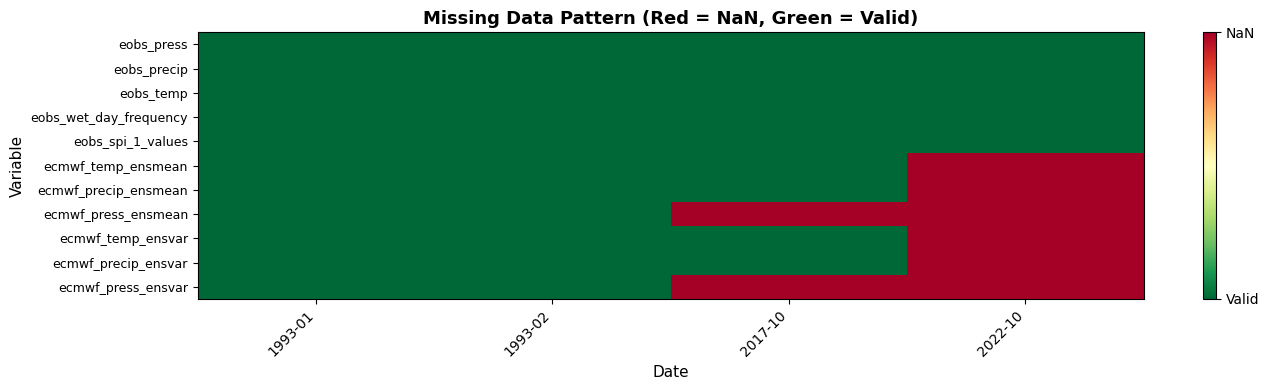


✓ NaN pattern visualization complete


In [ ]:
if len(rows_with_nan) > 0:
    # Get core variables (no lags)
    core_vars = [c for c in merged_df.columns 
                 if c not in ['time'] and not ('-1' in c or '-2' in c)]
    
    nan_subset = rows_with_nan[['time'] + core_vars].set_index('time')
    nan_binary = nan_subset.isnull().astype(int)
    
    # Plot
    if len(nan_binary) > 0:
        fig, ax = plt.subplots(figsize=(14, max(4, len(nan_binary)*0.3)))
        
        # Transpose for better visualization (variables as rows, dates as columns)
        im = ax.imshow(nan_binary.T, cmap='RdYlGn_r', aspect='auto', interpolation='nearest')
        
        # Labels
        ax.set_xticks(range(len(nan_binary)))
        ax.set_xticklabels([t.strftime('%Y-%m') for t in nan_binary.index], 
                          rotation=45, ha='right')
        ax.set_yticks(range(len(core_vars)))
        ax.set_yticklabels(core_vars, fontsize=9)
        
        ax.set_xlabel('Date', fontsize=11)
        ax.set_ylabel('Variable', fontsize=11)
        ax.set_title('Missing Data Pattern (Red = NaN, Green = Valid)', fontsize=13, fontweight='bold')
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
        cbar.ax.set_yticklabels(['Valid', 'NaN'])
        
        plt.tight_layout()
        plt.show()


# 6. Add Season Column

Add a categorical season column based on month:
- **Winter**: December, January, February (12, 1, 2)
- **Spring**: March, April, May (3, 4, 5)
- **Summer**: June, July, August (6, 7, 8)
- **Fall**: September, October, November (9, 10, 11)


In [45]:
def assign_season(month):
    """Map month number to season name."""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Fall'
    else:
        return None

# Add season column
merged_df['season'] = merged_df['time'].dt.month.apply(assign_season)

# Reorder columns to put season after time
cols = merged_df.columns.tolist()
cols.remove('season')
time_idx = cols.index('time')
cols.insert(time_idx + 1, 'season')
merged_df = merged_df[cols]

print("✓ Season column added (placed after 'time')")
print("\nSeason distribution:")
print(merged_df['season'].value_counts().sort_index())

print("\nFirst few rows:")
display(merged_df[['time', 'season', 'eobs_press', 'eobs_temp', 'eobs_precip']].head())


✓ Season column added (placed after 'time')

Season distribution:
season
Fall      93
Spring    93
Summer    93
Winter    93
Name: count, dtype: int64

First few rows:


,time,season,eobs_press,eobs_temp,eobs_precip
0,1993-01-31,Winter,998.94730,-5.261134,38.970314
1,1993-02-28,Winter,1018.13860,-4.456501,25.704689
2,1993-03-31,Spring,1014.49760,-3.907354,6.095313
3,1993-04-30,Spring,1014.26917,0.896708,9.868751
4,1993-05-31,Spring,1015.96890,7.252682,82.575005


# 7. Remove Rows with NaN Values

Remove rows containing NaN values to create a clean dataset for analysis.


In [ ]:
n_rows_before = len(merged_df)
n_nan_rows_before = merged_df.isnull().any(axis=1).sum()

merged_df_clean = merged_df.dropna().copy()

n_rows_after = len(merged_df_clean)
n_removed = n_rows_before - n_rows_after

remaining_nans = merged_df_clean.isnull().sum().sum()
print(f"\nRemaining NaN values: {remaining_nans}")
if remaining_nans == 0:
    print("✓ Dataset is now complete (no NaN values)")

# Show season distribution after cleaning
print("\nSeason distribution (after cleaning):")
season_counts = merged_df_clean['season'].value_counts().sort_index()
for season, count in season_counts.items():
    print(f"  {season:8s}: {count:3d} months")

# Show which dates were removed
if n_removed > 0:
    removed_dates = merged_df[merged_df.isnull().any(axis=1)]['time'].sort_values()
    print(f"\nRemoved dates ({n_removed} months):")
    for date in removed_dates:
        print(f"  - {date.strftime('%Y-%m-%d')}")


DATA CLEANING SUMMARY

Rows before cleaning: 372
Rows with NaN: 4
Rows removed: 4
Rows after cleaning: 368
Data retained: 98.9%

Remaining NaN values: 0
✓ Dataset is now complete (no NaN values)

Season distribution (after cleaning):
  Fall    :  91 months
  Spring  :  93 months
  Summer  :  93 months
  Winter  :  91 months

Removed dates (4 months):
  - 1993-01-31
  - 1993-02-28
  - 2017-10-31
  - 2022-10-31


# 8. Final Dataset Summary


In [ ]:
# Categorize columns
eobs_base = [c for c in merged_df_clean.columns if c.startswith('eobs_') and '-' not in c]
eobs_lag = [c for c in merged_df_clean.columns if c.startswith('eobs_') and '-' in c]
ecmwf_mean = [c for c in merged_df_clean.columns if 'ecmwf_' in c and 'ensmean' in c]
ecmwf_var = [c for c in merged_df_clean.columns if 'ecmwf_' in c and 'ensvar' in c]

merged_df_clean.head(3)

FINAL MERGED DATASET SUMMARY

Shape: (368, 19)
Time range: 1993-03-31 00:00:00 to 2023-12-31 00:00:00
Years covered: 31 years
Number of columns: 19

Column groups:
  E-OBS base variables: 5
  E-OBS lagged variables: 6
  ECMWF ensemble mean: 3
  ECMWF ensemble variance: 3
  Other (time, season): 2


,time,season,eobs_press,eobs_press_-1,eobs_press_-2,eobs_precip,eobs_precip_-1,eobs_precip_-2,eobs_temp,eobs_temp_-1,eobs_temp_-2,eobs_wet_day_frequency,eobs_spi_1_values,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensmean,ecmwf_temp_ensvar,ecmwf_precip_ensvar,ecmwf_press_ensvar
2,1993-03-31,Spring,1014.49760,1018.13860,998.9473,6.095313,25.704689,38.970314,-3.907354,-4.456501,-5.261134,0.121976,-1.862051,-6.818393,45.683977,1009.978842,1.784359,232.807868,34.732208
3,1993-04-30,Spring,1014.26917,1014.49760,1018.1386,9.868751,6.095313,25.704689,0.896708,-3.907354,-4.456501,0.151042,-1.329268,-2.247027,59.951233,1008.791816,0.943828,254.561116,9.658475
4,1993-05-31,Spring,1015.96890,1014.26917,1014.4976,82.575005,9.868751,6.095313,7.252682,0.896708,-3.907354,0.433972,1.124866,5.869891,74.586936,1017.762445,1.762311,1214.230474,4.808951


## 8.1 Statistical Summary by Variable Type


In [ ]:
summary_cols = [c for c in merged_df_clean.columns 
                if c not in ['time', 'season'] 
                and '-' not in c 
                and 'ensvar' not in c]

summary = merged_df_clean[summary_cols].describe()
display(summary)

Statistical Summary (base variables only):

Note: Excludes lagged variables and ensemble variance terms for clarity


,eobs_press,eobs_precip,eobs_temp,eobs_wet_day_frequency,eobs_spi_1_values,ecmwf_temp_ensmean,ecmwf_precip_ensmean,ecmwf_press_ensmean
count,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000,368.000000
mean,1011.507121,57.888503,1.588115,0.392602,0.122209,0.091997,73.006026,1011.659634
std,5.681915,33.975153,7.592749,0.137324,0.986897,8.622977,25.922113,3.728097
min,992.238400,1.942187,-14.924833,0.036458,-2.982115,-17.297626,31.147653,999.996875
25%,1008.819387,32.980078,-5.089186,0.303175,-0.439583,-7.998078,53.585917,1009.321569
50%,1011.487885,51.631249,0.891206,0.386719,0.236073,-0.027619,66.858000,1011.792277
75%,1014.725492,77.741405,8.349985,0.471855,0.719169,8.655950,88.660058,1013.907700
max,1029.921600,219.917180,16.586060,0.791146,3.875648,14.734015,151.112932,1024.300400


## 8.2 Compare E-OBS vs ECMWF Values


In [ ]:
print("\nComparing E-OBS observations vs ECMWF forecasts:")
print()

comparison_vars = [
    ('eobs_press', 'ecmwf_press_ensmean', 'Pressure'),
    ('eobs_temp', 'ecmwf_temp_ensmean', 'Temperature'),
    ('eobs_precip', 'ecmwf_precip_ensmean', 'Precipitation')
]

comparison_df = pd.DataFrame({
    'Variable': [],
    'EOBS_mean': [],
    'ECMWF_mean': [],
    'Difference': [],
    'EOBS_std': [],
    'ECMWF_std': []
})

for eobs_var, ecmwf_var, name in comparison_vars:
    eobs_mean = merged_df_clean[eobs_var].mean()
    ecmwf_mean = merged_df_clean[ecmwf_var].mean()
    diff = eobs_mean - ecmwf_mean
    eobs_std = merged_df_clean[eobs_var].std()
    ecmwf_std = merged_df_clean[ecmwf_var].std()
    
    comparison_df = pd.concat([comparison_df, pd.DataFrame({
        'Variable': [name],
        'EOBS_mean': [f"{eobs_mean:.2f}"],
        'ECMWF_mean': [f"{ecmwf_mean:.2f}"],
        'Difference': [f"{diff:+.2f}"],
        'EOBS_std': [f"{eobs_std:.2f}"],
        'ECMWF_std': [f"{ecmwf_std:.2f}"]
    })], ignore_index=True)

display(comparison_df)

CROSS-DATASET COMPARISON

Comparing E-OBS observations vs ECMWF forecasts:



,Variable,EOBS_mean,ECMWF_mean,Difference,EOBS_std,ECMWF_std
0,Pressure,1011.51,1011.66,-0.15,5.68,3.73
1,Temperature,1.59,0.09,+1.50,7.59,8.62
2,Precipitation,57.89,73.01,-15.12,33.98,25.92


## 8.3 Summary by Season


In [ ]:
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    season_df = merged_df_clean[merged_df_clean['season'] == season]
    print(f"\n{season}:")
    print(f"  Number of months: {len(season_df)}")
    print(f"  Mean temperature (E-OBS): {season_df['eobs_temp'].mean():.2f}°C")
    print(f"  Mean precipitation (E-OBS): {season_df['eobs_precip'].mean():.2f} mm")
    print(f"  Mean pressure (E-OBS): {season_df['eobs_press'].mean():.2f} hPa")

SEASONAL SUMMARY

Winter:
  Number of months: 91
  Mean temperature (E-OBS): -7.45°C
  Mean precipitation (E-OBS): 41.71 mm
  Mean pressure (E-OBS): 1009.89 hPa

Spring:
  Number of months: 93
  Mean temperature (E-OBS): 0.61°C
  Mean precipitation (E-OBS): 40.93 mm
  Mean pressure (E-OBS): 1013.01 hPa

Summer:
  Number of months: 93
  Mean temperature (E-OBS): 11.32°C
  Mean precipitation (E-OBS): 88.07 mm
  Mean pressure (E-OBS): 1011.34 hPa

Fall:
  Number of months: 91
  Mean temperature (E-OBS): 1.68°C
  Mean precipitation (E-OBS): 60.55 mm
  Mean pressure (E-OBS): 1011.77 hPa


# 9. Quick Validation Checks


In [ ]:
# Check 1: No NaNs
total_nans = merged_df_clean.isnull().sum().sum()

# Check 2: All months have a season
null_seasons = merged_df_clean['season'].isnull().sum()

# Check 3: Chronological order
time_sorted = merged_df_clean['time'].is_monotonic_increasing

# Check 4: Each season represented
seasons_present = set(merged_df_clean['season'].unique())
expected_seasons = {'Winter', 'Spring', 'Summer', 'Fall'}
all_seasons = seasons_present == expected_seasons
if not all_seasons:
    missing = expected_seasons - seasons_present

FINAL VALIDATION

✓ Check 1 - No NaN values: True (count: 0)
✓ Check 2 - All months have season: True (null count: 0)
✓ Check 3 - Time is chronologically ordered: True
✓ Check 4 - All four seasons present: True

✓ Check 5 - Value ranges:
  Temperature range: [-14.9, 16.6]°C
  Precipitation range: [1.9, 219.9] mm
  Pressure range: [992.2, 1029.9] hPa
  SPI-1 range: [-2.98, 3.88]

✓ ALL VALIDATION CHECKS PASSED
